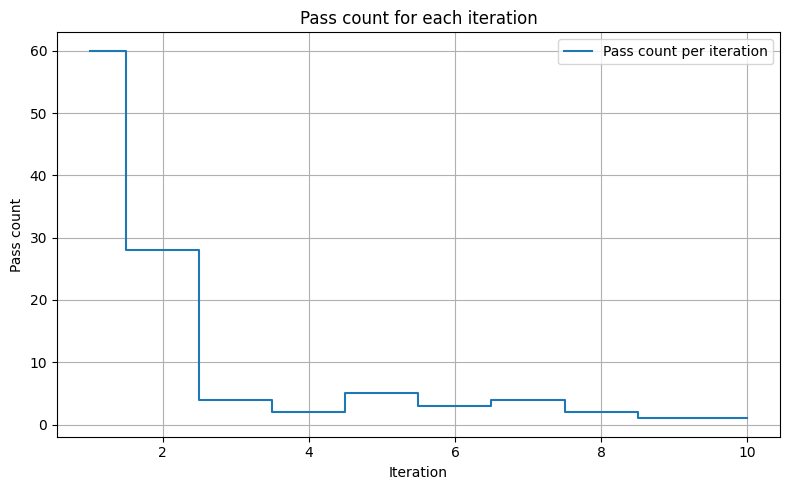

In [1]:
import csv
import matplotlib.pyplot as plt
from collections import Counter

csv_path = "data/ExVerus/parsed/exverus-ds-vb.parsed.table.with_status.csv"

iterations = []
with open(csv_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["pass_or_fail"] == "pass" and row["iteration"]:
            iterations.append(int(row["iteration"]))

counter = Counter(iterations)
# 按iteration升序
x = sorted(counter.keys())
y = [counter[i] for i in x]

plt.figure(figsize=(8, 5))
plt.step(x, y, where='mid', label='Pass count per iteration')
plt.xlabel("Iteration")
plt.ylabel("Pass count")
plt.title("Pass count for each iteration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

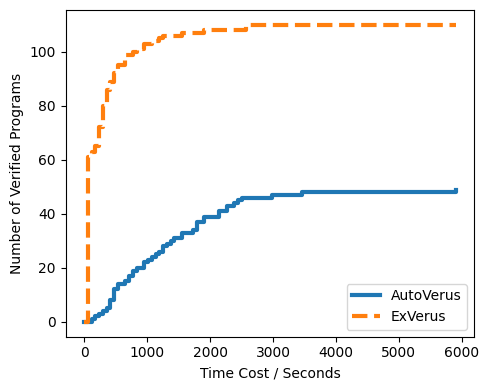

In [3]:
import os
import csv
import matplotlib.pyplot as plt
import numpy as np

# 1. ExVerus: 收集所有 pass 的 duration_s_total
exverus_csv = "data/ExVerus/parsed/exverus-ds-vb.parsed.table.with_status.csv"
exverus_times = []
with open(exverus_csv, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["pass_or_fail"] == "pass":
            exverus_times.append(float(row["duration_s_total"]))
exverus_times.sort()

# 2. Autoverus: 收集所有 verified==True 的 runtime_seconds
autoverus_dir = "data/Autoverus"
autoverus_times = []
for fname in os.listdir(autoverus_dir):
    if fname.endswith(".csv"):
        with open(os.path.join(autoverus_dir, fname), "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                if "verified" in row and row["verified"].strip().lower() == "true":
                    autoverus_times.append(float(row["runtime_seconds"]))
autoverus_times.sort()

# 3. 构造时间阈值序列（比如0~最大时间，步长10秒）
max_time = max(exverus_times + autoverus_times)
time_thresholds = np.linspace(0, max_time, 100)

def count_pass(times, thresholds):
    return [np.searchsorted(times, t, side='right') for t in thresholds]

exverus_pass_counts = count_pass(exverus_times, time_thresholds)
autoverus_pass_counts = count_pass(autoverus_times, time_thresholds)

# 4. 绘图
plt.figure(figsize=(5, 4))
plt.step(time_thresholds, autoverus_pass_counts, where='post', label="AutoVerus", linewidth=3, color="#1f77b4")
plt.step(time_thresholds, exverus_pass_counts, where='post', label="ExVerus", linewidth=3, color="#ff7f0e", linestyle="--")
plt.xlabel("Time Cost / Seconds")
plt.ylabel("Number of Verified Programs")
plt.legend(loc='lower right')  
plt.tight_layout()
plt.savefig("time_cost_2.pdf") 
plt.show()


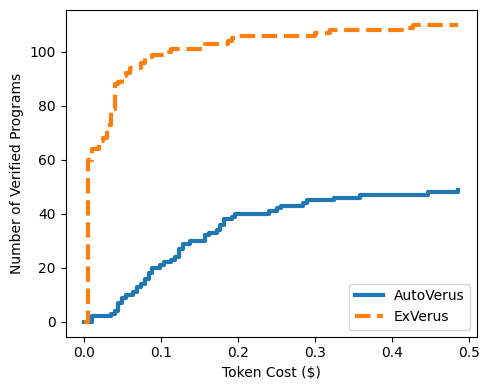

In [5]:
import os
import csv
import matplotlib.pyplot as plt
import numpy as np

# 1. ExVerus: 收集所有 pass 的 cost
exverus_csv = "data/ExVerus/parsed/exverus-ds-vb.parsed.table.with_status.csv"
exverus_costs = []
with open(exverus_csv, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["pass_or_fail"] == "pass":
            prompt_tokens = float(row["prompt_tokens_total"])
            completion_tokens = float(row["completion_tokens_total"])
            cost = (prompt_tokens * 0.56 + completion_tokens * 1.68) / 1_000_000
            exverus_costs.append(cost)
exverus_costs.sort()

# 2. Autoverus: 收集所有 verified==True 的 cost
autoverus_dir = "data/Autoverus"
autoverus_costs = []
for fname in os.listdir(autoverus_dir):
    if fname.endswith(".csv"):
        with open(os.path.join(autoverus_dir, fname), "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                if "verified" in row and row["verified"].strip().lower() == "true":
                    input_tokens = float(row["input_tokens_total"])
                    output_tokens = float(row["output_tokens_total"])
                    cost = (input_tokens * 0.56 + output_tokens * 1.68) / 1_000_000
                    autoverus_costs.append(cost)
autoverus_costs.sort()

# 3. 构造 cost 阈值序列
max_cost = max(exverus_costs + autoverus_costs)
cost_thresholds = np.linspace(0, max_cost, 100)

def count_pass(costs, thresholds):
    return [np.searchsorted(costs, t, side='right') for t in thresholds]

exverus_pass_counts = count_pass(exverus_costs, cost_thresholds)
autoverus_pass_counts = count_pass(autoverus_costs, cost_thresholds)

plt.figure(figsize=(5, 4))
plt.step(cost_thresholds, autoverus_pass_counts, where='post', label="AutoVerus", linewidth=3, color="#1f77b4")
plt.step(cost_thresholds, exverus_pass_counts, where='post', label="ExVerus", linewidth=3, color="#ff7f0e", linestyle="--")
plt.xlabel("Token Cost ($)")
plt.ylabel("Number of Verified Programs")
plt.legend(loc='lower right')  # 图注放在右下角
plt.tight_layout()
plt.savefig("token_cost_2.pdf") 
plt.show()